# Convolutional Autoencoder (CAE) cho ảnh vệ tinh Himawari-8 — phiên bản PyTorch

Notebook này giữ nguyên toàn bộ **pipeline, cấu trúc, tiền xử lý, kiến trúc và phương pháp đánh giá** của phiên bản TensorFlow/Keras trước đó. Điểm khác biệt duy nhất:

- Framework chuyển từ **TensorFlow/Keras → PyTorch**.
- Kích thước ảnh đầu vào chuyển từ 128×128 → **512×512** (theo yêu cầu mới).
- Bổ sung **Batch Normalization** sau `Conv2D(128)` và `Conv2D(256)` (đúng theo sơ đồ kiến trúc mới).
- Bổ sung **L1 regularization** và **L2 regularization (weight decay)**.
- Bổ sung đánh giá **SSIM** và **similarity theo phần trăm**.
- Bổ sung giải thích toán học cho reconstruction loss.
- `Dataset`/`DataLoader` dùng **lazy loading** (chỉ đọc ảnh từ đĩa khi cần, không load toàn bộ vào RAM) để pipeline có thể mở rộng lên ~200,000 ảnh mà không cần sửa code.

**Pipeline tổng quát (không đổi):**

```
Ảnh gốc → Encoder → Latent Representation → Decoder → Ảnh tái tạo
```

## 1. Import libraries

Chỉ dùng PyTorch để xây dựng và train model (không dùng TensorFlow/Keras). Các thư viện phụ trợ (NumPy, Matplotlib, PIL) giữ nguyên như bản TensorFlow. `scikit-learn` dùng để chia train/validation, `scikit-image` dùng để tính SSIM/PSNR.

In [2]:
import os
import glob
import random

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from tqdm.auto import tqdm

from sklearn.model_selection import train_test_split
from skimage.metrics import peak_signal_noise_ratio as psnr_metric
from skimage.metrics import structural_similarity as ssim_metric

# Cố định seed để kết quả có thể tái lập (reproducible) — giữ nguyên như bản TensorFlow
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

## 2. Configuration

Khai báo đường dẫn dataset, kích thước ảnh, và các **hyperparameter**. Giải thích từng hyperparameter:

- **`IMG_SIZE = 512`**: kích thước ảnh đầu vào cố định — toàn bộ kiến trúc Encoder/Decoder được thiết kế dựa trên con số này.
- **`BATCH_SIZE = 8`**: số ảnh xử lý cùng lúc trong mỗi bước cập nhật gradient. Batch nhỏ (8) phù hợp với dataset nhỏ (10–15 ảnh) và cũng tiết kiệm bộ nhớ khi ảnh có kích thước lớn (512×512); khi dataset mở rộng lên hàng trăm nghìn ảnh, có thể tăng `BATCH_SIZE` mà không cần sửa logic code.
- **`EPOCHS = 100`**: số lần model duyệt qua toàn bộ tập train. Với dataset rất nhỏ, 100 epoch là khá nhiều nên `EarlyStopping` thủ công (theo dõi `val_loss`) sẽ được dùng ở bước training để tránh overfitting/lãng phí thời gian.
- **`LEARNING_RATE = 1e-3`**: tốc độ học của optimizer Adam — bước nhảy mỗi lần cập nhật trọng số theo hướng ngược gradient. Giá trị này càng lớn thì model học càng nhanh nhưng dễ dao động/khó hội tụ; càng nhỏ thì học ổn định hơn nhưng chậm hơn. `1e-3` là giá trị mặc định phổ biến, cân bằng tốt giữa tốc độ và ổn định cho Adam.
- **`L1_LAMBDA`**: hệ số phạt **L1 regularization** — cộng thêm vào loss một lượng tỉ lệ với tổng trị tuyệt đối của toàn bộ trọng số (`Σ|w|`). L1 có xu hướng đẩy nhiều trọng số về đúng 0, giúp model "thưa" (sparse) hơn, có thể loại bỏ bớt các kết nối không quan trọng.
- **`L2_WEIGHT_DECAY`**: hệ số **L2 regularization** (hay còn gọi "weight decay") — cộng thêm vào loss một lượng tỉ lệ với tổng bình phương trọng số (`Σw²`). Trong PyTorch, L2 được cấu hình trực tiếp qua tham số `weight_decay` của optimizer Adam thay vì cộng thủ công vào loss. L2 có xu hướng làm trọng số nhỏ đều (không đẩy về đúng 0 như L1), giúp model tránh việc một vài trọng số trở nên quá lớn (giảm overfitting).
- Cả L1 và L2 đều là kỹ thuật **regularization**: mục đích là hạn chế model học "quá khớp" (overfit) với tập train nhỏ, bằng cách phạt các trọng số có độ lớn không cần thiết.

In [3]:
# --- Đường dẫn dataset ---
DATASET_DIR = "dataset"  # thư mục chứa 2 thư mục con: train/ và test/
TRAIN_DIR = os.path.join(DATASET_DIR, "train")
TEST_DIR = os.path.join(DATASET_DIR, "test")

# --- Kích thước ảnh ---
IMG_SIZE = 512
CHANNELS = 1

# --- Hyperparameters ---
BATCH_SIZE = 8
EPOCHS = 100
LEARNING_RATE = 1e-3
L1_LAMBDA = 1e-5          # hệ số L1 regularization
L2_WEIGHT_DECAY = 1e-5    # hệ số L2 regularization (weight decay trong Adam)
EARLY_STOPPING_PATIENCE = 20

# --- Tự động phát hiện GPU ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Bật cudnn.benchmark: cuDNN sẽ dò và cache thuật toán convolution nhanh nhất
# cho shape input cố định (512x512) - giúp tăng tốc và ổn định tốc độ mỗi step.
# Chỉ nên bật khi input shape không đổi giữa các batch (đúng với bài toán này).
if device.type == "cuda":
    torch.backends.cudnn.benchmark = True

print("Đang sử dụng thiết bị:", device)
if device.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("Không tìm thấy GPU — sẽ chạy trên CPU (vẫn ổn với dataset nhỏ).")

Đang sử dụng thiết bị: cpu
Không tìm thấy GPU — sẽ chạy trên CPU (vẫn ổn với dataset nhỏ).


## 3. Load image paths

Chỉ tìm và lưu lại **đường dẫn file** (`.png`), chưa đọc nội dung ảnh vào bộ nhớ. Đây là điểm quan trọng để pipeline có thể mở rộng lên ~200,000 ảnh: dù dataset có bao nhiêu ảnh, bước này chỉ tốn bộ nhớ để lưu danh sách string (đường dẫn), không tốn bộ nhớ để lưu pixel.

In [6]:
import os
import glob
from sklearn.model_selection import train_test_split

DATASET_DIR = r"C:\Users\quang\PycharmProjects\JupyterProject\output"

all_paths = sorted(
    glob.glob(os.path.join(DATASET_DIR, "*.png"))
)

# Tự động chia 80% train - 20% test
train_paths, test_paths = train_test_split(
    all_paths,
    test_size=0.2,
    random_state=42
)

print(f"Tổng số ảnh tìm thấy: {len(all_paths)}")
print(f"Số ảnh train: {len(train_paths)}")
print(f"Số ảnh test:  {len(test_paths)}")

assert len(train_paths) > 0, (
    "Không tìm thấy ảnh .png nào trong thư mục output — "
    "kiểm tra lại DATASET_DIR."
)


Tổng số ảnh tìm thấy: 37
Số ảnh train: 29
Số ảnh test:  8


## 4. Load raw images

Hàm `load_raw_images` đọc ảnh gốc (chưa xử lý) bằng PIL — dùng cho mục đích **xem trước/so sánh trực quan** (Cell tiếp theo) trên một tập nhỏ, KHÔNG dùng để load toàn bộ dataset lớn vào RAM. Việc load dữ liệu thật để training được thực hiện lazy (từng ảnh một, khi cần) trong lớp `Dataset` ở phần 6.

In [7]:
def load_raw_images(paths):
    """Đọc danh sách ảnh PNG, trả về list các PIL.Image (giữ nguyên gốc).
    Chỉ nên dùng cho một tập nhỏ (ví dụ để visualize), không dùng cho toàn bộ
    dataset lớn vì sẽ tốn nhiều RAM."""
    images = []
    for p in paths:
        img = Image.open(p)
        images.append(img)
    return images

# Load thử một tập nhỏ để demo/visualize
preview_paths = train_paths[:4]
raw_preview_images = load_raw_images(preview_paths)
print(f"Đã load {len(raw_preview_images)} ảnh mẫu để xem trước.")
print("Kích thước ảnh đầu tiên (gốc):", raw_preview_images[0].size, "| mode:", raw_preview_images[0].mode)

Đã load 4 ảnh mẫu để xem trước.
Kích thước ảnh đầu tiên (gốc): (1500, 1200) | mode: LA


## 5. Preprocessing

Giữ nguyên quy trình tiền xử lý như bản TensorFlow, chỉ đổi `IMG_SIZE` thành 512:

1. Chuyển ảnh về **grayscale**.
2. **Resize** về `512 × 512` bằng bộ lọc **LANCZOS**.
3. **Normalize** giá trị pixel về `[0, 1]`.
4. Thêm channel dimension → shape `(512, 512, 1)`.

Hàm `preprocess_dataset` ở đây chỉ dùng để xử lý các tập nhỏ đã load sẵn (ví dụ tập preview) — với dataset lớn, việc preprocess từng ảnh sẽ được gọi lazy bên trong `Dataset` (phần 6), tránh phải giữ toàn bộ ảnh đã xử lý trong RAM cùng lúc.

Shape sau preprocessing (tập preview): (4, 512, 512, 1)


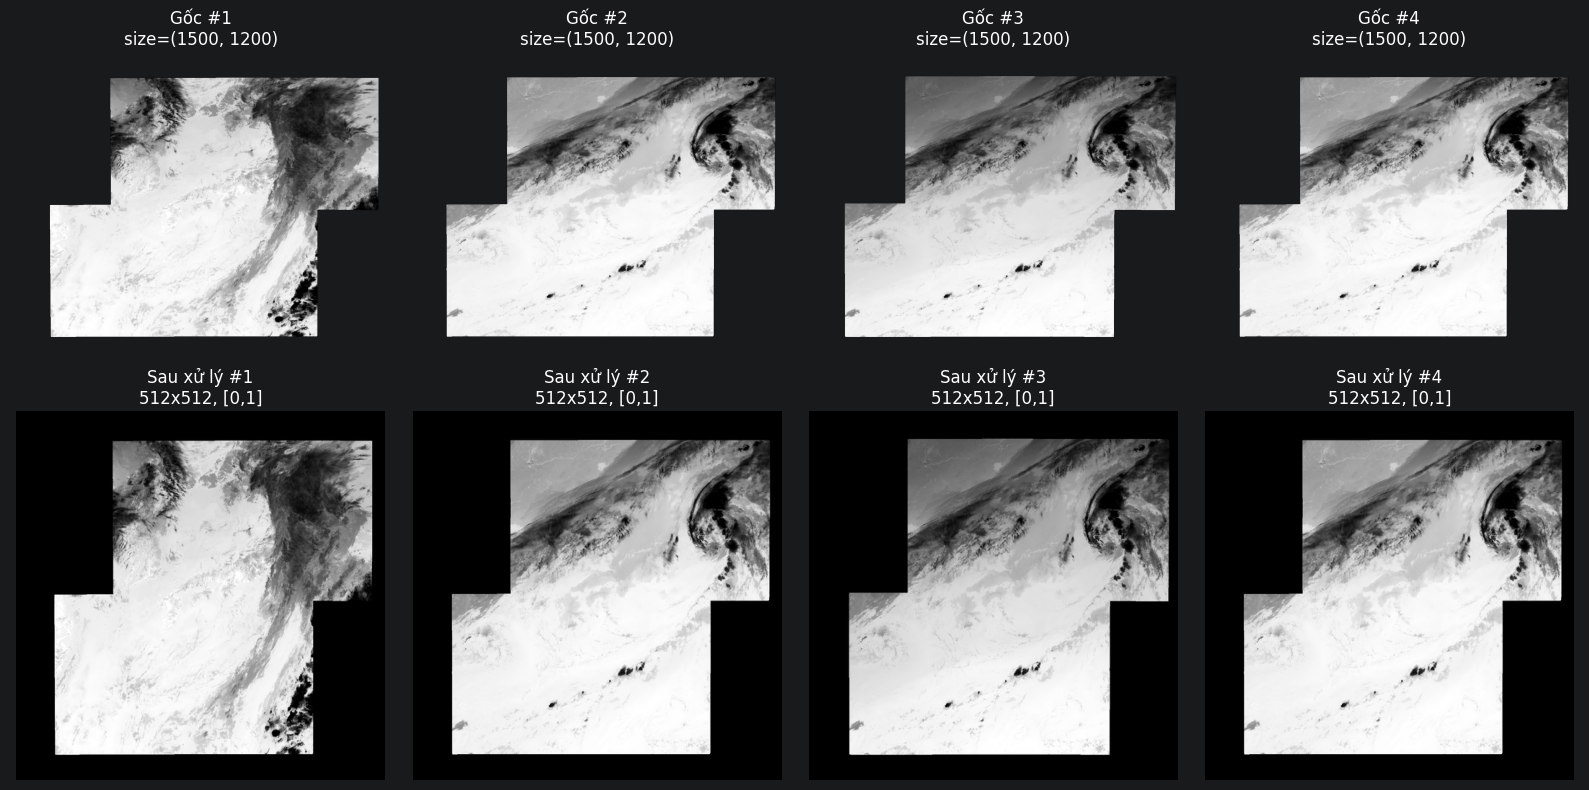

In [8]:
def preprocess_image(img: Image.Image, size=IMG_SIZE):
    """Grayscale -> resize (LANCZOS) -> normalize [0,1] -> shape (size, size, 1)"""
    if img.mode != "L":
        img = img.convert("L")
    img = img.resize((size, size), Image.LANCZOS)
    arr = np.array(img).astype("float32") / 255.0
    arr = np.expand_dims(arr, axis=-1)  # (H, W) -> (H, W, 1)
    return arr

def preprocess_dataset(images):
    """Áp dụng preprocess_image cho một list ảnh PIL đã load sẵn.
    Chỉ dùng cho tập nhỏ (preview/visualize), không dùng cho toàn bộ dataset lớn."""
    return np.stack([preprocess_image(img) for img in images], axis=0)

# Xử lý thử tập preview để kiểm tra
preview_processed = preprocess_dataset(raw_preview_images)
print("Shape sau preprocessing (tập preview):", preview_processed.shape)

# So sánh trực quan ảnh trước/sau preprocessing
n_show = len(raw_preview_images)
fig, axes = plt.subplots(2, n_show, figsize=(4 * n_show, 8))
for i in range(n_show):
    axes[0, i].imshow(raw_preview_images[i], cmap="gray")
    axes[0, i].set_title(f"Gốc #{i+1}\nsize={raw_preview_images[i].size}")
    axes[0, i].axis("off")

    axes[1, i].imshow(preview_processed[i].squeeze(), cmap="gray", vmin=0, vmax=1)
    axes[1, i].set_title(f"Sau xử lý #{i+1}\n{IMG_SIZE}x{IMG_SIZE}, [0,1]")
    axes[1, i].axis("off")
plt.tight_layout()
plt.show()

## 6. Dataset

Đây là phần **thay đổi cần thiết để phù hợp với PyTorch** (theo đúng yêu cầu "Chuyển dữ liệu sang định dạng phù hợp với PyTorch"): xây dựng lớp `HimawariDataset` kế thừa `torch.utils.data.Dataset`.

Điểm thiết kế quan trọng: `__getitem__` chỉ đọc và tiền xử lý **một ảnh tại một thời điểm**, ngay khi được gọi (lazy loading) — thay vì load toàn bộ dataset vào RAM một lần như mảng NumPy ở bản TensorFlow trước. Nhờ vậy, dù dataset có 15 ảnh hay 200,000 ảnh, mức RAM sử dụng tại một thời điểm là như nhau — chỉ phụ thuộc `BATCH_SIZE`, không phụ thuộc tổng số ảnh. Đây chính là cơ chế giúp pipeline **mở rộng được lên ~200,000 ảnh mà không cần sửa code**.

Ảnh được trả về dưới dạng tensor PyTorch có shape `(C, H, W)` = `(1, 512, 512)` — đúng quy ước channel-first mà PyTorch yêu cầu (khác với TensorFlow dùng channel-last `(H, W, C)`).

In [9]:
class HimawariDataset(Dataset):
    """Dataset lazy-loading: chỉ đọc + tiền xử lý 1 ảnh khi __getitem__ được gọi.
    Có thể dùng với dataset từ vài ảnh đến hàng trăm nghìn ảnh mà không đổi code."""

    def __init__(self, image_paths, img_size=IMG_SIZE):
        self.image_paths = image_paths
        self.img_size = img_size

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img = Image.open(self.image_paths[idx])
        arr = preprocess_image(img, size=self.img_size)      # (H, W, 1), float32 [0,1]
        tensor = torch.from_numpy(arr).permute(2, 0, 1)       # (H, W, 1) -> (1, H, W)
        return tensor.float()

print("Đã định nghĩa lớp HimawariDataset (lazy-loading).")

Đã định nghĩa lớp HimawariDataset (lazy-loading).


## 7. DataLoader

Chia danh sách **đường dẫn** train thành train/validation (không chia mảng ảnh đã load, để giữ tính lazy-loading), sau đó tạo `Dataset` và `DataLoader` cho từng tập. `DataLoader` tự động gom nhiều ảnh thành từng batch, xáo trộn thứ tự (`shuffle=True` cho tập train) và có thể chạy song song bằng nhiều tiến trình con (`num_workers`) khi dataset lớn.

Giống như bản TensorFlow: nếu dataset quá nhỏ (<5 ảnh) để chia validation có ý nghĩa thống kê, dùng luôn tập train làm validation kèm cảnh báo.

In [10]:
n_train_total = len(train_paths)
if n_train_total >= 5:
    train_split_paths, val_split_paths = train_test_split(
        train_paths, test_size=max(1, int(0.2 * n_train_total)), random_state=SEED
    )
else:
    print("[Cảnh báo] Dataset quá nhỏ (<5 ảnh) để chia validation có ý nghĩa thống kê.")
    print("           Dùng toàn bộ tập train làm validation (chỉ mang tính tham khảo).")
    train_split_paths, val_split_paths = train_paths, train_paths

train_dataset = HimawariDataset(train_split_paths)
val_dataset = HimawariDataset(val_split_paths)

# batch_size không vượt quá số ảnh hiện có trong từng tập
train_batch_size = min(BATCH_SIZE, len(train_dataset))
val_batch_size = min(BATCH_SIZE, len(val_dataset))

# num_workers > 0: dùng nhiều tiến trình con để đọc/tiền xử lý ảnh song song,
#   chuẩn bị sẵn batch tiếp theo trong lúc GPU đang tính batch hiện tại
#   (tránh GPU phải chờ CPU -> tăng % sử dụng GPU).
# pin_memory=True: dữ liệu được cấp phát ở vùng RAM "pinned", giúp việc chuyển
#   dữ liệu CPU -> GPU nhanh hơn.
# persistent_workers=True: giữ các tiến trình con sống xuyên suốt nhiều epoch,
#   tránh tốn thời gian khởi tạo lại worker ở đầu mỗi epoch.
NUM_WORKERS = min(4, os.cpu_count() or 1)

train_loader = DataLoader(
    train_dataset, batch_size=train_batch_size, shuffle=True,
    num_workers=NUM_WORKERS, pin_memory=(device.type == "cuda"),
    persistent_workers=(NUM_WORKERS > 0),
)
val_loader = DataLoader(
    val_dataset, batch_size=val_batch_size, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=(device.type == "cuda"),
    persistent_workers=(NUM_WORKERS > 0),
)

print(f"Số ảnh train: {len(train_dataset)} | Số ảnh validation: {len(val_dataset)}")
print(f"Batch size train/val: {train_batch_size}/{val_batch_size}")

# Kiểm tra nhanh 1 batch
sample_batch = next(iter(train_loader))
print("Shape 1 batch train:", sample_batch.shape)  # (B, 1, 512, 512)

Số ảnh train: 24 | Số ảnh validation: 5
Batch size train/val: 8/5


RuntimeError: DataLoader worker (pid(s) 24360, 9228, 15912, 10228) exited unexpectedly

## 8. Build Encoder

Kiến trúc Encoder theo đúng sơ đồ mới, giữ nguyên nguyên lý (Conv2D để trích đặc trưng, MaxPooling2D để giảm kích thước không gian và tăng độ trừu tượng của đặc trưng), bổ sung **Batch Normalization** sau `Conv2D(128)` và `Conv2D(256)` đúng như sơ đồ yêu cầu:

```
Input (512×512×1)
  → Conv2D(32) → MaxPooling2D            : 512×512×32 → 256×256×32
  → Conv2D(64) → MaxPooling2D            : 256×256×64 → 128×128×64
  → Conv2D(128) + BatchNorm → MaxPooling2D : 128×128×128 → 64×64×128
  → Conv2D(256) + BatchNorm              : 64×64×256   (= Latent Space)
```

**Batch Normalization** chuẩn hóa lại phân phối giá trị đầu ra của mỗi lớp Conv (đưa về trung bình ~0, phương sai ~1) trước khi qua hàm kích hoạt. Lợi ích: giúp quá trình training ổn định hơn, cho phép dùng learning rate lớn hơn mà không phân kỳ, và giảm phụ thuộc vào cách khởi tạo trọng số ban đầu.

In [11]:
class Encoder(nn.Module):
    def __init__(self, in_channels=CHANNELS):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels, 32, kernel_size=3, padding=1)
        self.pool1 = nn.MaxPool2d(kernel_size=2)

        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.pool2 = nn.MaxPool2d(kernel_size=2)

        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(128)
        self.pool3 = nn.MaxPool2d(kernel_size=2)

        self.conv4 = nn.Conv2d(128, 256, kernel_size=3, padding=1)
        self.bn4 = nn.BatchNorm2d(256)

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = self.pool1(x)          # 256x256x32

        x = F.relu(self.conv2(x))
        x = self.pool2(x)          # 128x128x64

        x = F.relu(self.bn3(self.conv3(x)))
        x = self.pool3(x)          # 64x64x128

        latent = F.relu(self.bn4(self.conv4(x)))  # 64x64x256  <-- Latent Space
        return latent

encoder = Encoder().to(device)
print(encoder)

Encoder(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (pool3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv4): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn4): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
)


## 9. Build Decoder

Kiến trúc Decoder theo đúng sơ đồ mới, dùng `ConvTranspose2d` để tăng dần kích thước không gian, đối xứng ngược lại với Encoder:

```
Latent Space (64×64×256)
  → ConvTranspose2D(256), stride=1  : 64×64×256   (xử lý đặc trưng ở latent, chưa phóng to)
  → ConvTranspose2D(128), stride=2  : 64×64 → 128×128×128
  → ConvTranspose2D(64),  stride=2  : 128×128 → 256×256×64
  → ConvTranspose2D(32),  stride=2  : 256×256 → 512×512×32
  → Conv2D(1, sigmoid)              : 512×512×1  (Ảnh tái tạo)
```

3 lớp `ConvTranspose2D` dùng `stride=2` để nhân đôi kích thước không gian ở mỗi bước (đối xứng với 3 lớp `MaxPooling2D` ở Encoder). Lớp `ConvTranspose2D(256)` đầu tiên dùng `stride=1` để tiếp tục xử lý đặc trưng ngay tại độ phân giải của latent space trước khi bắt đầu phóng to. Lớp cuối dùng `sigmoid` để đưa giá trị pixel về đúng khoảng `[0, 1]`, khớp với dữ liệu đầu vào đã normalize.

In [12]:
class Decoder(nn.Module):
    def __init__(self, out_channels=CHANNELS):
        super().__init__()
        self.deconv1 = nn.ConvTranspose2d(256, 256, kernel_size=3, stride=1, padding=1)
        self.deconv2 = nn.ConvTranspose2d(256, 128, kernel_size=4, stride=2, padding=1)
        self.deconv3 = nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1)
        self.deconv4 = nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1)
        self.conv_out = nn.Conv2d(32, out_channels, kernel_size=3, padding=1)

    def forward(self, x):
        x = F.relu(self.deconv1(x))   # 64x64x256
        x = F.relu(self.deconv2(x))   # 128x128x128
        x = F.relu(self.deconv3(x))   # 256x256x64
        x = F.relu(self.deconv4(x))   # 512x512x32
        out = torch.sigmoid(self.conv_out(x))  # 512x512x1
        return out

decoder = Decoder().to(device)
print(decoder)

Decoder(
  (deconv1): ConvTranspose2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (deconv2): ConvTranspose2d(256, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
  (deconv3): ConvTranspose2d(128, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
  (deconv4): ConvTranspose2d(64, 32, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
  (conv_out): Conv2d(32, 1, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
)


## 10. Build Autoencoder

Ghép `Encoder` và `Decoder` thành một lớp `Autoencoder` hoàn chỉnh, kế thừa `torch.nn.Module`. `encoder` và `decoder` vẫn giữ vai trò là hai module độc lập bên trong, có thể truy cập riêng qua `autoencoder.encoder` / `autoencoder.decoder` để lấy latent representation hoặc decode một latent tuỳ ý — tương đương với việc tạo 3 model `encoder`, `decoder`, `autoencoder` riêng biệt như bản TensorFlow.

In [13]:
class Autoencoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = Encoder()
        self.decoder = Decoder()

    def forward(self, x):
        latent = self.encoder(x)
        reconstructed = self.decoder(latent)
        return reconstructed

autoencoder = Autoencoder().to(device)

n_params = sum(p.numel() for p in autoencoder.parameters())
n_trainable = sum(p.numel() for p in autoencoder.parameters() if p.requires_grad)
print(f"Tổng số tham số: {n_params:,}")
print(f"Số tham số có thể train: {n_trainable:,}")

# Kiểm tra shape đầu ra
with torch.no_grad():
    test_input = torch.randn(1, CHANNELS, IMG_SIZE, IMG_SIZE).to(device)
    test_output = autoencoder(test_input)
    test_latent = autoencoder.encoder(test_input)
print("Input shape:      ", tuple(test_input.shape))
print("Latent shape:      ", tuple(test_latent.shape))
print("Output shape:      ", tuple(test_output.shape))

Tổng số tham số: 1,667,329
Số tham số có thể train: 1,667,329
Input shape:       (1, 1, 512, 512)
Latent shape:       (1, 256, 64, 64)
Output shape:       (1, 1, 512, 512)


## 11. Training

### Toán học của reconstruction loss

Loss chính là **MSE (Mean Squared Error)** giữa ảnh gốc $x$ và ảnh tái tạo $\hat{x}$, tính trung bình trên toàn bộ pixel:

$$
\mathcal{L}_{MSE}(x, \hat{x}) = \frac{1}{N} \sum_{i=1}^{N} (x_i - \hat{x}_i)^2
$$

trong đó $N$ là tổng số pixel (ở đây $N = 512 \times 512 = 262{,}144$ pixel/ảnh), $x_i$ và $\hat{x}_i$ lần lượt là giá trị pixel thứ $i$ của ảnh gốc và ảnh tái tạo (đã normalize về $[0,1]$).

### Bổ sung L1 và L2 regularization

Loss tổng cộng dùng để backpropagate là:

$$
\mathcal{L}_{total} = \mathcal{L}_{MSE}(x, \hat{x}) \;+\; \lambda_1 \sum_{w \in \theta} |w| \;+\; \lambda_2 \sum_{w \in \theta} w^2
$$

trong đó $\theta$ là tập toàn bộ trọng số của model, $\lambda_1$ = `L1_LAMBDA`, $\lambda_2$ = `L2_WEIGHT_DECAY`.

- Số hạng $\lambda_1 \sum |w|$ (**L1**) được cộng **thủ công** vào loss trong vòng lặp training (PyTorch không hỗ trợ sẵn L1 qua optimizer).
- Số hạng $\lambda_2 \sum w^2$ (**L2 / weight decay**) được PyTorch tính **tự động** bên trong optimizer Adam thông qua tham số `weight_decay=L2_WEIGHT_DECAY` — về mặt toán học tương đương với việc cộng $\lambda_2 \sum w^2$ vào loss trước khi lấy đạo hàm.

### Vòng lặp training

Huấn luyện theo mini-batch bằng `DataLoader`, dùng `EarlyStopping` thủ công (theo dõi `val_loss`, dừng nếu không cải thiện sau `EARLY_STOPPING_PATIENCE` epoch) và lưu lại trọng số tốt nhất — giữ đúng nguyên lý như `EarlyStopping`/`ModelCheckpoint` ở bản TensorFlow.

In [14]:
optimizer = optim.Adam(autoencoder.parameters(), lr=LEARNING_RATE, weight_decay=L2_WEIGHT_DECAY)
criterion = nn.MSELoss()

def l1_penalty(model, lam):
    """Tính số hạng L1 regularization: lambda1 * sum(|w|) trên toàn bộ trọng số."""
    l1 = sum(p.abs().sum() for p in model.parameters())
    return lam * l1

train_losses, val_losses = [], []
best_val_loss = float("inf")
best_state_dict = None
epochs_no_improve = 0

epoch_bar = tqdm(range(1, EPOCHS + 1), desc="Training", unit="epoch")
for epoch in epoch_bar:
    # ----- Training -----
    autoencoder.train()
    running_loss = 0.0
    for batch in train_loader:
        batch = batch.to(device, non_blocking=True)

        optimizer.zero_grad()
        outputs = autoencoder(batch)
        loss = criterion(outputs, batch) + l1_penalty(autoencoder, L1_LAMBDA)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * batch.size(0)
    train_loss = running_loss / len(train_dataset)

    # ----- Validation -----
    autoencoder.eval()
    running_val_loss = 0.0
    with torch.no_grad():
        for batch in val_loader:
            batch = batch.to(device, non_blocking=True)
            outputs = autoencoder(batch)
            loss = criterion(outputs, batch)  # không cộng L1 khi đánh giá validation
            running_val_loss += loss.item() * batch.size(0)
    val_loss = running_val_loss / len(val_dataset)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    # Cập nhật train_loss/val_loss ngay trên thanh tiến trình tqdm
    epoch_bar.set_postfix(train_loss=f"{train_loss:.6f}", val_loss=f"{val_loss:.6f}",
                           best_val=f"{best_val_loss:.6f}")

    # ----- Early stopping thủ công -----
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_state_dict = {k: v.clone() for k, v in autoencoder.state_dict().items()}
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= EARLY_STOPPING_PATIENCE:
            tqdm.write(f"Early stopping tại epoch {epoch} (val_loss không cải thiện sau {EARLY_STOPPING_PATIENCE} epoch).")
            break

# Khôi phục trọng số tốt nhất (tương đương restore_best_weights=True ở Keras)
if best_state_dict is not None:
    autoencoder.load_state_dict(best_state_dict)
    print(f"\nĐã khôi phục trọng số tốt nhất (val_loss = {best_val_loss:.6f}).")

Training:   0%|          | 0/100 [00:00<?, ?epoch/s]

RuntimeError: DataLoader worker (pid(s) 24360, 9228, 15912, 10228) exited unexpectedly

## 12. Evaluation

Giữ nguyên phương pháp đánh giá như bản TensorFlow (MSE, MAE, PSNR), bổ sung thêm **SSIM** và cách quy đổi **similarity theo phần trăm**.

### Công thức các metric

- **MSE** (đã nêu ở phần 11): $\mathcal{L}_{MSE} = \frac{1}{N}\sum (x_i - \hat{x}_i)^2$ — càng nhỏ càng tốt.
- **MAE** (Mean Absolute Error): $\mathcal{L}_{MAE} = \frac{1}{N}\sum |x_i - \hat{x}_i|$ — càng nhỏ càng tốt, ít nhạy với outlier hơn MSE.
- **PSNR** (Peak Signal-to-Noise Ratio), đơn vị dB:

$$
PSNR = 10 \cdot \log_{10}\left(\frac{MAX^2}{MSE}\right)
$$

  với $MAX = 1$ (vì ảnh đã normalize về $[0,1]$). PSNR càng cao thì ảnh tái tạo càng gần ảnh gốc.

- **SSIM** (Structural Similarity Index) — so sánh độ giống nhau về **cấu trúc** (structure), **độ sáng** (luminance) và **độ tương phản** (contrast) giữa hai ảnh, thay vì so sánh pixel-by-pixel đơn thuần như MSE:

$$
SSIM(x, \hat{x}) = \frac{(2\mu_x \mu_{\hat{x}} + c_1)(2\sigma_{x\hat{x}} + c_2)}{(\mu_x^2 + \mu_{\hat{x}}^2 + c_1)(\sigma_x^2 + \sigma_{\hat{x}}^2 + c_2)}
$$

  trong đó $\mu$ là giá trị trung bình, $\sigma^2$ là phương sai, $\sigma_{x\hat{x}}$ là hiệp phương sai (covariance) giữa hai ảnh, $c_1, c_2$ là hằng số nhỏ để tránh chia cho 0. SSIM nằm trong khoảng $[-1, 1]$, giá trị `1` nghĩa là hai ảnh giống hệt nhau.

### Similarity theo phần trăm

Vì SSIM đã được thiết kế để phản ánh mức độ giống nhau về mặt cảm quan (giống mắt người nhìn hơn MSE thuần túy), ta quy đổi trực tiếp sang phần trăm:

$$
\text{Similarity}(\%) = \max(0, SSIM(x, \hat{x})) \times 100\%
$$

(giá trị SSIM âm — hiếm khi xảy ra trong bài toán reconstruction — được chặn về 0% vì về mặt trực quan không có ý nghĩa "giống bao nhiêu phần trăm" khi SSIM âm).

In [ ]:
autoencoder.eval()

# Dùng tập test nếu có, nếu không thì dùng tập validation
if len(test_paths) > 0:
    eval_paths = test_paths
    eval_source = "tập test"
else:
    eval_paths = val_split_paths
    eval_source = "tập validation (do không có ảnh test)"

print(f"Đánh giá trên {eval_source}, gồm {len(eval_paths)} ảnh.")

eval_dataset = HimawariDataset(eval_paths)
eval_loader = DataLoader(eval_dataset, batch_size=min(BATCH_SIZE, len(eval_dataset)), shuffle=False)

originals_list, reconstructed_list = [], []
with torch.no_grad():
    for batch in eval_loader:
        batch = batch.to(device)
        outputs = autoencoder(batch)
        originals_list.append(batch.cpu().numpy())
        reconstructed_list.append(outputs.cpu().numpy())

originals = np.concatenate(originals_list, axis=0)          # (N, 1, 512, 512)
reconstructed = np.concatenate(reconstructed_list, axis=0)  # (N, 1, 512, 512)
reconstructed = np.clip(reconstructed, 0, 1)

# ----- Tính các metric -----
mse_val = np.mean((originals - reconstructed) ** 2)
mae_val = np.mean(np.abs(originals - reconstructed))

psnr_values, ssim_values = [], []
for i in range(len(originals)):
    orig_img = originals[i, 0]
    recon_img = reconstructed[i, 0]
    psnr_values.append(psnr_metric(orig_img, recon_img, data_range=1.0))
    ssim_values.append(ssim_metric(orig_img, recon_img, data_range=1.0))

psnr_val = float(np.mean(psnr_values))
ssim_val = float(np.mean(ssim_values))
similarity_percent = max(0.0, ssim_val) * 100

print(f"MSE trung bình:        {mse_val:.6f}")
print(f"MAE trung bình:        {mae_val:.6f}")
print(f"PSNR trung bình:       {psnr_val:.2f} dB")
print(f"SSIM trung bình:       {ssim_val:.4f}")
print(f"Similarity (theo %):   {similarity_percent:.2f}%")

## 13. Visualization

### Biểu đồ training/validation loss

Cách diễn giải giữ nguyên như bản TensorFlow: loss giảm dần nghĩa là model học tốt hơn; nếu `train_loss` tiếp tục giảm nhưng `val_loss` tăng trở lại thì đó là dấu hiệu overfitting; với dataset rất nhỏ, đường `val_loss` có thể dao động mạnh nên cần kết hợp đánh giá bằng mắt (nhìn ảnh tái tạo) chứ không chỉ dựa vào con số.

### Hàm `visualize(img, encoder, decoder)`

Hiển thị đúng luồng: **Ảnh gốc → Latent representation → Ảnh tái tạo**. Vì latent space có tới 256 channel (không thể hiển thị hết), ta hiển thị **giá trị trung bình theo channel** (mean activation map, shape 64×64) như một cách xấp xỉ trực quan hoá latent representation.

In [ ]:
# --- Biểu đồ Training / Validation Loss ---
plt.figure(figsize=(8, 5))
plt.plot(train_losses, label="Training Loss")
plt.plot(val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss (+ L1 penalty ở phần train)")
plt.title("Quá trình training của Autoencoder (PyTorch)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print(f"Loss cuối cùng - train: {train_losses[-1]:.6f} | val: {val_losses[-1]:.6f}")
print(f"Loss thấp nhất - train: {min(train_losses):.6f} | val: {min(val_losses):.6f}")

In [ ]:
def visualize(img_tensor, encoder, decoder):
    """Hiển thị: Original image -> Encoded representation -> Reconstructed image.
    img_tensor: tensor shape (1, H, W) hoặc (H, W) - một ảnh đã preprocess."""
    encoder.eval()
    decoder.eval()

    if img_tensor.dim() == 2:
        img_tensor = img_tensor.unsqueeze(0)  # (H,W) -> (1,H,W)
    batch = img_tensor.unsqueeze(0).to(device)  # (1, 1, H, W)

    with torch.no_grad():
        latent = encoder(batch)                 # (1, 256, 64, 64)
        reconstructed = decoder(latent)          # (1, 1, H, W)

    original_np = batch.cpu().numpy()[0, 0]
    latent_mean_np = latent.cpu().numpy()[0].mean(axis=0)   # mean qua 256 channel -> (64,64)
    reconstructed_np = np.clip(reconstructed.cpu().numpy()[0, 0], 0, 1)

    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    axes[0].imshow(original_np, cmap="gray", vmin=0, vmax=1)
    axes[0].set_title("Original image")
    axes[0].axis("off")

    axes[1].imshow(latent_mean_np, cmap="viridis")
    axes[1].set_title("Encoded representation\n(mean qua 256 channel, 64x64)")
    axes[1].axis("off")

    axes[2].imshow(reconstructed_np, cmap="gray", vmin=0, vmax=1)
    axes[2].set_title("Reconstructed image")
    axes[2].axis("off")

    plt.tight_layout()
    plt.show()

# Demo hàm visualize trên 1 ảnh mẫu từ tập đánh giá
sample_tensor = torch.from_numpy(originals[0])  # (1, H, W)
visualize(sample_tensor, autoencoder.encoder, autoencoder.decoder)

In [ ]:
# --- So sánh ít nhất 5 cặp ảnh Original / Reconstructed ---
n_show = min(5, len(originals))
fig, axes = plt.subplots(2, n_show, figsize=(3 * n_show, 6))
for i in range(n_show):
    axes[0, i].imshow(originals[i, 0], cmap="gray", vmin=0, vmax=1)
    axes[0, i].set_title(f"Original #{i+1}")
    axes[0, i].axis("off")

    axes[1, i].imshow(reconstructed[i, 0], cmap="gray", vmin=0, vmax=1)
    axes[1, i].set_title(f"Reconstructed #{i+1}\nSSIM={ssim_values[i]:.3f}")
    axes[1, i].axis("off")
plt.tight_layout()
plt.show()

## 14. Save model

Lưu trọng số (`state_dict`) của `encoder`, `decoder`, và `autoencoder` bằng `torch.save()` — tương đương việc lưu 3 file `.keras` riêng biệt ở bản TensorFlow. Lưu `state_dict` (chỉ trọng số) thay vì lưu nguyên object model là cách làm được khuyến nghị trong PyTorch — giúp việc load lại linh hoạt và ít lỗi hơn giữa các phiên bản code.

In [ ]:
torch.save(autoencoder.encoder.state_dict(), "encoder.pth")
torch.save(autoencoder.decoder.state_dict(), "decoder.pth")
torch.save(autoencoder.state_dict(), "autoencoder.pth")

print("Đã lưu: encoder.pth, decoder.pth, autoencoder.pth")

## 15. Load model

Khởi tạo lại kiến trúc model (`Encoder`, `Decoder`, `Autoencoder`), sau đó dùng `torch.load()` + `load_state_dict()` để nạp lại trọng số đã lưu. Chạy thử lại trên 1 ảnh để xác nhận model load lên hoạt động đúng như model gốc.

In [ ]:
loaded_encoder = Encoder().to(device)
loaded_decoder = Decoder().to(device)
loaded_autoencoder = Autoencoder().to(device)

loaded_encoder.load_state_dict(torch.load("encoder.pth", map_location=device))
loaded_decoder.load_state_dict(torch.load("decoder.pth", map_location=device))
loaded_autoencoder.load_state_dict(torch.load("autoencoder.pth", map_location=device))

loaded_encoder.eval()
loaded_decoder.eval()
loaded_autoencoder.eval()

# Kiểm tra bằng cách chạy lại trên 1 ảnh mẫu
sample_batch = torch.from_numpy(originals[:1]).to(device)
with torch.no_grad():
    sample_reconstructed = loaded_autoencoder(sample_batch)

fig, axes = plt.subplots(1, 2, figsize=(6, 3))
axes[0].imshow(sample_batch.cpu().numpy()[0, 0], cmap="gray", vmin=0, vmax=1)
axes[0].set_title("Original")
axes[0].axis("off")

axes[1].imshow(np.clip(sample_reconstructed.cpu().numpy()[0, 0], 0, 1), cmap="gray", vmin=0, vmax=1)
axes[1].set_title("Reconstructed (model đã load lại)")
axes[1].axis("off")

plt.tight_layout()
plt.show()

print("Model load lại hoạt động đúng như mong đợi.")